# 4. Triage Pipeline: OOD Detection + Resolution Suggestions + Comparison


1. **OOD detection**- flag complaints that don't look financial at all
2. **Resolution suggestion** - retrieval-based
3. **End-to-end triage function**-  text in -> category, urgency, OOD |flag, suggested resolution out
4. **Final model comparison**-  TF-IDF vs DistilBERT, both tasks (urgency and product detection)


In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import pickle
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path.cwd().parent / 'src'))
from resolution_suggester import suggest_resolution
from ood_detector import OODDetector

DATA_DIR = Path.cwd().parent / 'data'
MODEL_DIR = Path.cwd().parent / 'models'

import joblib

vectorizer = joblib.load(MODEL_DIR / 'tfidf_vectorizer.joblib')

category_clf = joblib.load(MODEL_DIR / 'tfidf_category_logreg.joblib')


## 4.1 Fit the OOD detector

Combines softmax confidence with embedding-distance to the nearest known
category centroid (using a small sentence-transformer). A complaint that's
both low-confidence AND far from every known cluster gets flagged as
out-of-scope instead of force-classified.


In [ ]:
ood_detector = OODDetector().fit(df['text'], df['product'])
ood_detector.save(MODEL_DIR / 'ood_detector.pkl')
print(f"Fit on {len(df)} rows, {len(ood_detector.centroid_labels)} category centroids.")

In [4]:
# testing
test_queries = [
    "there is a fraudulent charge on my credit card that I never made",
    "my mortgage servicer will not tell me why my escrow payment went up",
    "what's the weather like today",
    "can you recommend a good pizza place nearby",
    "write me a poem about the ocean",
]

for q in test_queries:
    dist, nearest = ood_detector.nearest_centroid_distance(q)
    print(f"'{q}'\n  nearest_category={nearest}  cosine_dist={dist:.3f}\n")

'there is a fraudulent charge on my credit card that I never made'
  nearest_category=Credit card or prepaid card  cosine_dist=0.306

'my mortgage servicer will not tell me why my escrow payment went up'
  nearest_category=Mortgage  cosine_dist=0.350

'what's the weather like today'
  nearest_category=Mortgage  cosine_dist=1.000

'can you recommend a good pizza place nearby'
  nearest_category=Credit card or prepaid card  cosine_dist=1.057

'write me a poem about the ocean'
  nearest_category=Credit reporting, credit repair services, or other personal consumer reports  cosine_dist=1.004



## 4.2 End-to-end triage function

Same logic reused by the Streamlit app (`app/app.py`).


In [5]:
def predict_category(text, vectorizer, clf):
    X = vectorizer.transform([text])
    if hasattr(clf, 'predict_proba'):
        probs = clf.predict_proba(X)[0]
        confidence = probs.max()
    else:
        margins = clf.decision_function(X)[0]
        confidence = float(1 / (1 + np.exp(-np.max(margins))))
    pred = clf.predict(X)[0]
    return pred, confidence


def triage(text, vectorizer, category_clf, ood_detector):
    category, confidence = predict_category(text, vectorizer, category_clf)
    is_ood, reason, details = ood_detector.is_ood(text, confidence)

    result = {'query': text, 'in_scope': not is_ood}
    if is_ood:
        result['reason'] = reason
        result['details'] = details
        return result

    result['category'] = category
    result['confidence'] = confidence
    result['resolution'] = suggest_resolution(category)
    return result


In [6]:
for q in test_queries:
    result = triage(q, vectorizer, category_clf, ood_detector)
    print(f"Query: {result['query']}")
    if result['in_scope']:
        print(f"  Category: {result['category']}  (confidence={result['confidence']:.1%})")
        print(f"  Suggested resolution: {result['resolution']}")
    else:
        print(f"  OUT OF SCOPE -- {result['reason']}")
    print()


Query: there is a fraudulent charge on my credit card that I never made
  Category: Credit card  (confidence=45.3%)
  Suggested resolution: Dispute the specific transaction/fee with your card issuer in writing citing the date and amount; issuers must acknowledge billing disputes within 30 days.

Query: my mortgage servicer will not tell me why my escrow payment went up
  Category: Mortgage  (confidence=83.4%)
  Suggested resolution: Request a written explanation from your servicer and, if it involves missed payments, ask about loss-mitigation / loan-modification options before any foreclosure step. Escalate to CFPB if the servicer doesn't respond within 30 days.

Query: what's the weather like today
  OUT OF SCOPE -- low confidence AND far from all known clusters

Query: can you recommend a good pizza place nearby
  OUT OF SCOPE -- low confidence AND far from all known clusters

Query: write me a poem about the ocean
  OUT OF SCOPE -- low confidence AND far from all known clusters



## 4.3 Full model comparison

Pulls together TF-IDF baselines (notebook 2) and DistilBERT results
(notebook 3) into one table + plot for the write-up.


In [7]:
rows = []

baseline_path = MODEL_DIR / 'baseline_results.csv'
if baseline_path.exists():
    baseline = pd.read_csv(baseline_path, index_col=0)
    for name, r in baseline.iterrows():
        rows.append({'model': name, 'accuracy': r['accuracy'], 'macro_f1': r['macro_f1']})

db_path = MODEL_DIR / 'distilbert_results.csv'
if db_path.exists():
    db = pd.read_csv(db_path)
    for _, r in db.iterrows():
        rows.append({'model': r['model'], 'accuracy': r['accuracy'], 'macro_f1': r['macro_f1']})

comparison_df = pd.DataFrame(rows).set_index('model')
comparison_df

,accuracy,macro_f1
model,,
category_logreg,0.853933,0.653202
category_svm,0.878277,0.656563
urgency_logreg,0.748127,0.639895
urgency_svm,0.755618,0.605084
distilbert_category,0.788333,0.490755
distilbert_urgency,0.638333,0.499458


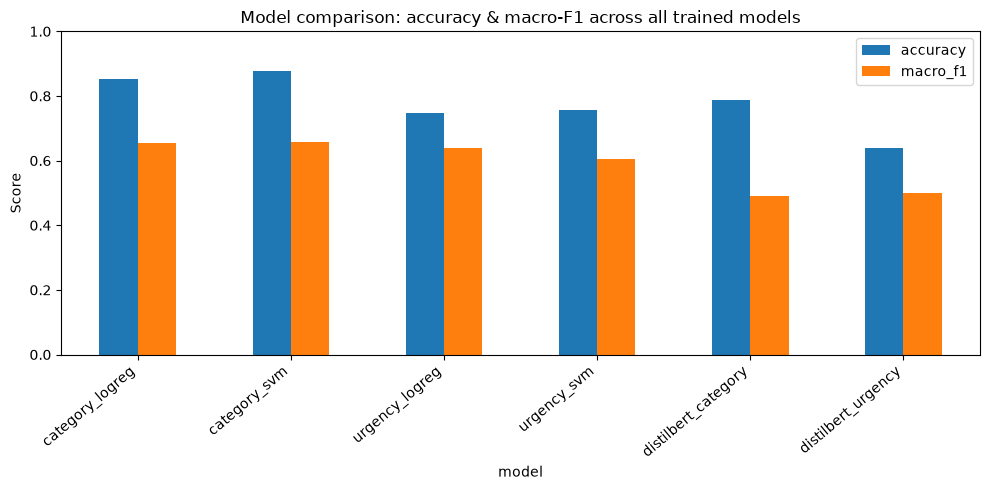

In [8]:
if len(comparison_df):
    fig, ax = plt.subplots(figsize=(10,5))
    comparison_df[['accuracy','macro_f1']].plot(kind='bar', ax=ax)
    ax.set_title('Model comparison: accuracy & macro-F1 across all trained models')
    ax.set_ylabel('Score'); ax.set_ylim(0,1)
    plt.xticks(rotation=40, ha='right')
    plt.tight_layout()
    plt.savefig(MODEL_DIR / 'comparison_plot.png', dpi=150)
    plt.show()


In [ ]:
#interactive demo
!cd .. && streamlit run app/app.py


In [11]:
import sys
print(sys.executable)

C:\Users\narul\AppData\Local\Programs\Python\Python313\python.exe
